# Validation Pipeline Sketch V4
## 0. Imports and Set-Up:

### 0.1 Imports, Seed-Setting, Plotting-Helper-Function:

In [120]:
import multiprocessing
import random

from dataclasses import dataclass, field
from joblib import Parallel, delayed
from pathlib import Path
from typing import Any, Callable, Optional, Type

from tqdm.notebook import tqdm

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

from sklearn.base import ClusterMixin, TransformerMixin
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, pairwise_distances
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, FunctionTransformer, StandardScaler

from scipy import sparse
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

from umap import UMAP

import matplotlib.pyplot as plt

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

### 0.2 Helper Functions:

In [58]:
def plot_dim_reduced_clustering(
    X: np.ndarray, 
    clusters: np.ndarray, 
    method: str = 'PCA', 
    perplexity: int = 30, 
    n_neighbors: int = 15, 
    min_dist: float = 0.1,
    ax: plt.Axes = None, 
    show: bool = True
) -> plt.Axes:
    """
    Plot a 2D embedding of the data colored by cluster assignments.

    :param X: the input data matrix to be reduced and plotted (n_samples, n_features)
    :param clusters: cluster labels for each sample (n_samples,)
    :param method: dimensionality reduction method to use; either 'PCA' or 'tSNE'
    :param ax: a matplotlib axes object to be plotted on
    :param show: controls whether to call plt.show()

    :return: plt.Axes if show = False, otherwise displays a scatter plot with the samples colored by cluster assignment
    """
    # dimensionality reduction
    if method == 'PCA':
        X_red = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X)
    elif method == 'tSNE':
        X_red = TSNE(
            n_components=2,
            random_state=RANDOM_SEED,
            perplexity=perplexity
        ).fit_transform(X)
    elif method == 'UMAP':
        X_red = UMAP(
            n_components=2, 
            n_neighbors=n_neighbors, 
            min_dist=min_dist, 
            random_state=RANDOM_SEED  # throws a warning
        ).fit_transform(X)
    else:
        raise ValueError(f"Unknown dimensionality reduction method {method}. Use one of 'PCA', 'tSNE', or 'UMAP'.")

    # build discrete colormap for clusters
    unique_clusters = np.unique(clusters)
    base_cmap = plt.get_cmap('Set1', len(unique_clusters))
    color_dict = {lab: base_cmap(i) for i, lab in enumerate(unique_clusters)}

    # plot points
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))
    point_colors = [color_dict[lab] for lab in clusters]
    ax.scatter(X_red[:, 0], X_red[:, 1], c=point_colors, s=10, alpha=0.8)

    # handle legend
    for lab in unique_clusters:
        ax.scatter([], [], c=[color_dict[lab]], label=f"cluster {lab}", s=50, alpha=0.8)
        
    ax.legend(loc='lower right', frameon=False)

    # titles & axis labels
    if method == 'PCA':
        ax.set(
            title="PCA of Data Set",
            xlabel="PCA 1",
            ylabel="PCA 2"
        )
    elif method == 'tSNE':
        ax.set(
            title="t-SNE of Data Set",
            xlabel="t-SNE 1",
            ylabel="t-SNE 2"
        )
    else:
        ax.set(
            title="UMAP of Data Set",
            xlabel="UMAP 1",
            ylabel="UMAP 2"
        )

    if show:
        plt.tight_layout()
        plt.show()
    else:
        return ax

In [4]:
def subsample_indices(n_samples: int, ratio: float = 0.8, random_state: int = None) -> tuple[np.ndarray, np.ndarray]:
    """
    draw a subsample of indices of size floor(ratio * n_samples).
    
    :param n_samples: total number of samples in data frame.
    :param ratio: ratio for subsampling, between 0 and 1. 
    :param random_state: random seed for rng.
    
    :return:
        train_idx: 1D array of length floor(ratio * n_samples).
        test_idx: the complement indices (length = n_samples - len(train_idx)).
    """
    rng = np.random.RandomState(random_state)
    all_idx = np.arange(n_samples)
    train_size = int(np.float64(ratio * n_samples))
    
    train_idx = rng.choice(all_idx, size=train_size, replace=False)
    test_idx = np.setdiff1d(all_idx, train_idx)
    
    return train_idx, test_idx

In [5]:
def update_consensus_count(C: np.ndarray, labels_full: np.ndarray) -> None:
    """
    increment C[i,j] by 1 for every pair i,j that share the same cluster label.
    
    :param C: consensus matrix.
    :param labels_full: 1D array length = n_samples, where each entry is an integer cluster ID.
    
    :return: None (C is updated in place)
    """
    for cluster_id in np.unique(labels_full):
        members = np.where(labels_full == cluster_id)[0]
        
        for i in members:
            C[i, members] += 1
    
    return None

### 0.3 Data Import:

PANCAN dataset:

In [113]:
data_dir = Path('./data/TCGA-PANCAN-HiSeq-801x20531')
data_fp = data_dir / 'data.csv'
labels_fp = data_dir / 'labels.csv'

labels = pd.read_csv(labels_fp, header=None, skiprows=1)

sample = pd.read_csv(data_fp, header=None, skiprows=1, nrows=100, low_memory=False)
numeric_cols = [
    col
    for col in sample.columns
    if pd.to_numeric(sample[col], errors='coerce').notna().all()
]

print(f"found {len(numeric_cols)} numeric cols out of {len(sample.columns)}")

data = pd.read_csv(
    data_fp,
    header=None,
    usecols=numeric_cols,
    skiprows=1, 
    dtype=float,
    low_memory=False
)

le = LabelEncoder()
y = le.fit_transform(labels[1])

X = data.values

print("X shape:", X.shape, " |  y shape:", y.shape)

found 20531 numeric cols out of 20532
X shape: (801, 20531)  |  y shape: (801,)


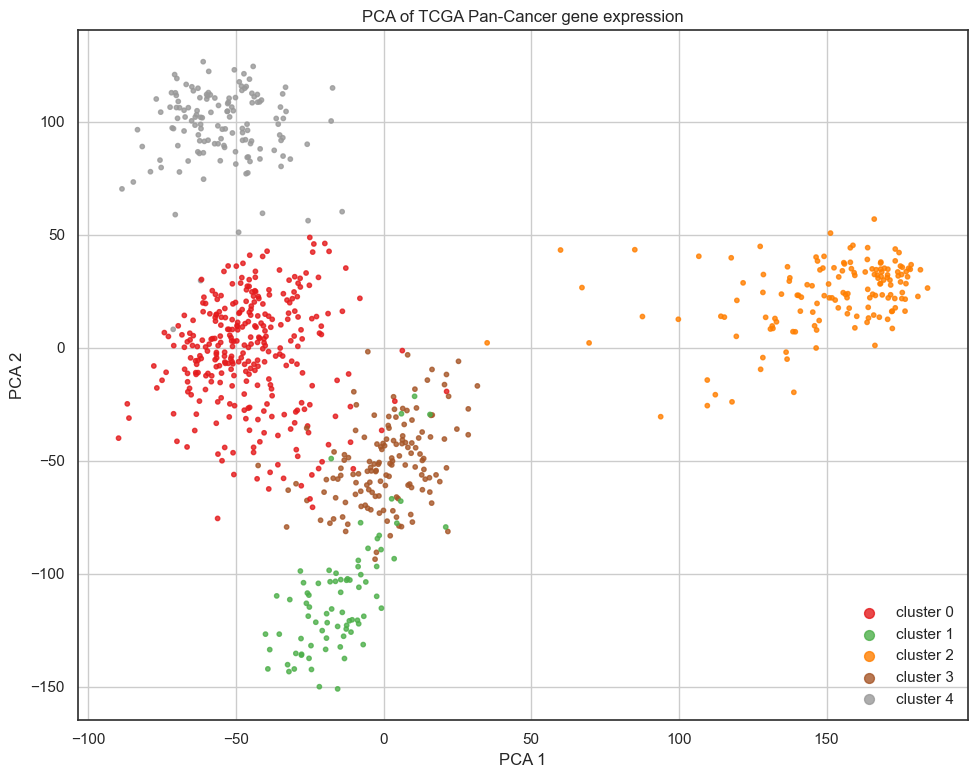

In [141]:
plot_dim_reduced_clustering(X, y, method='PCA')

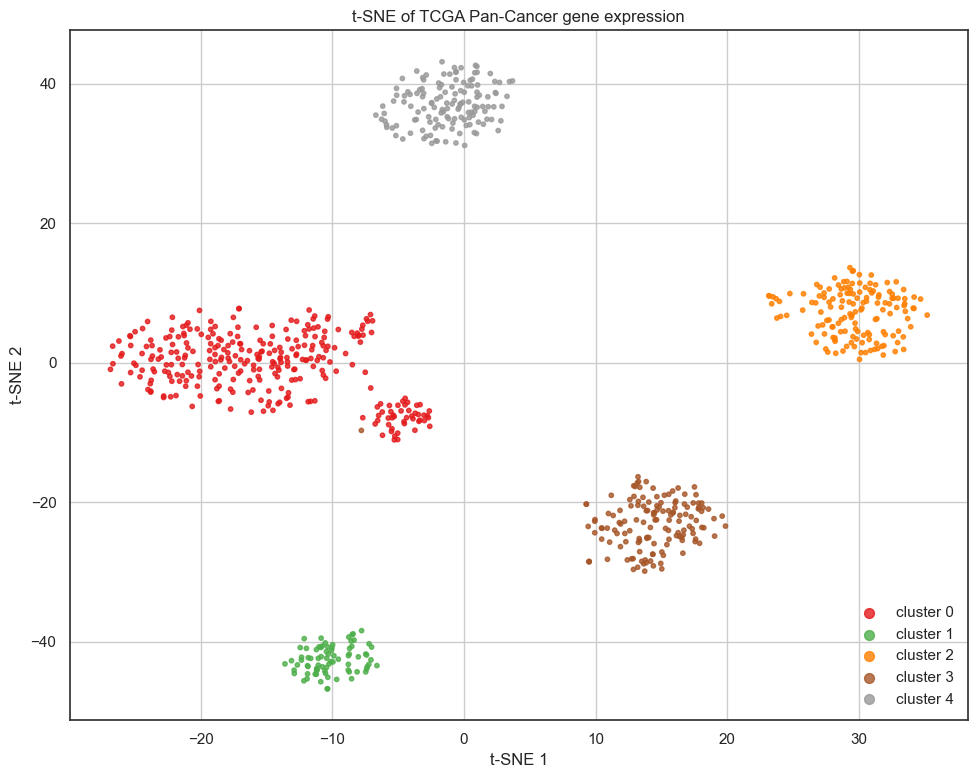

In [142]:
plot_dim_reduced_clustering(X, y, method='tSNE')

/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


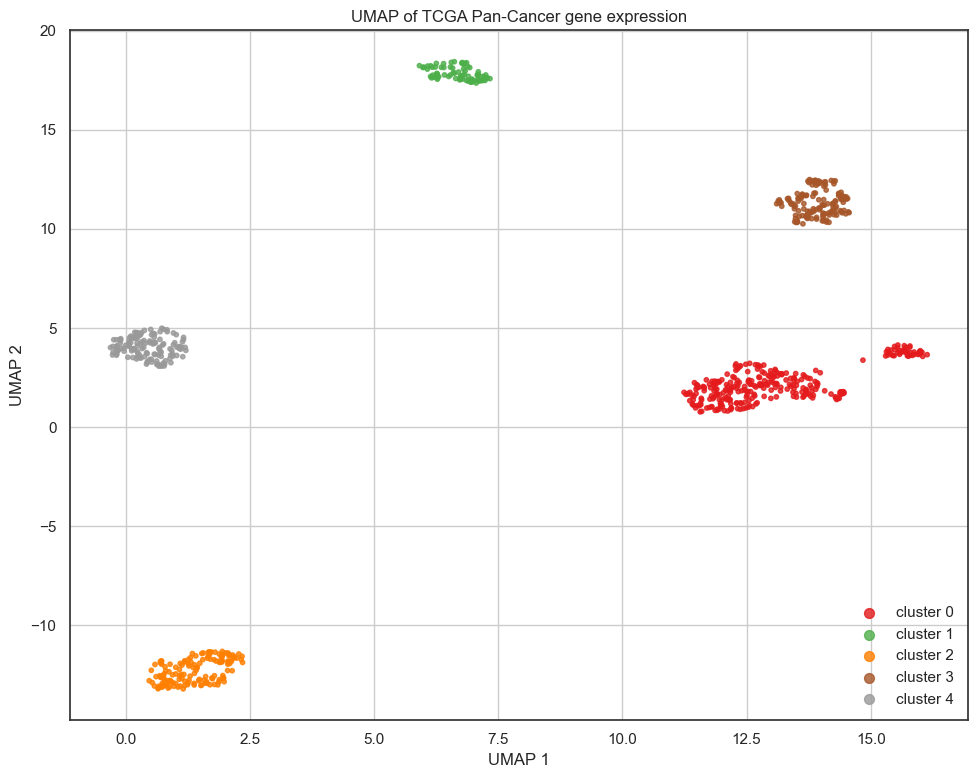

In [143]:
plot_dim_reduced_clustering(X, y, method='UMAP')

IRIS dataset:

In [6]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

print("X shape:", X.shape, " |  y shape:", y.shape)

X shape: (150, 4)  |  y shape: (150,)


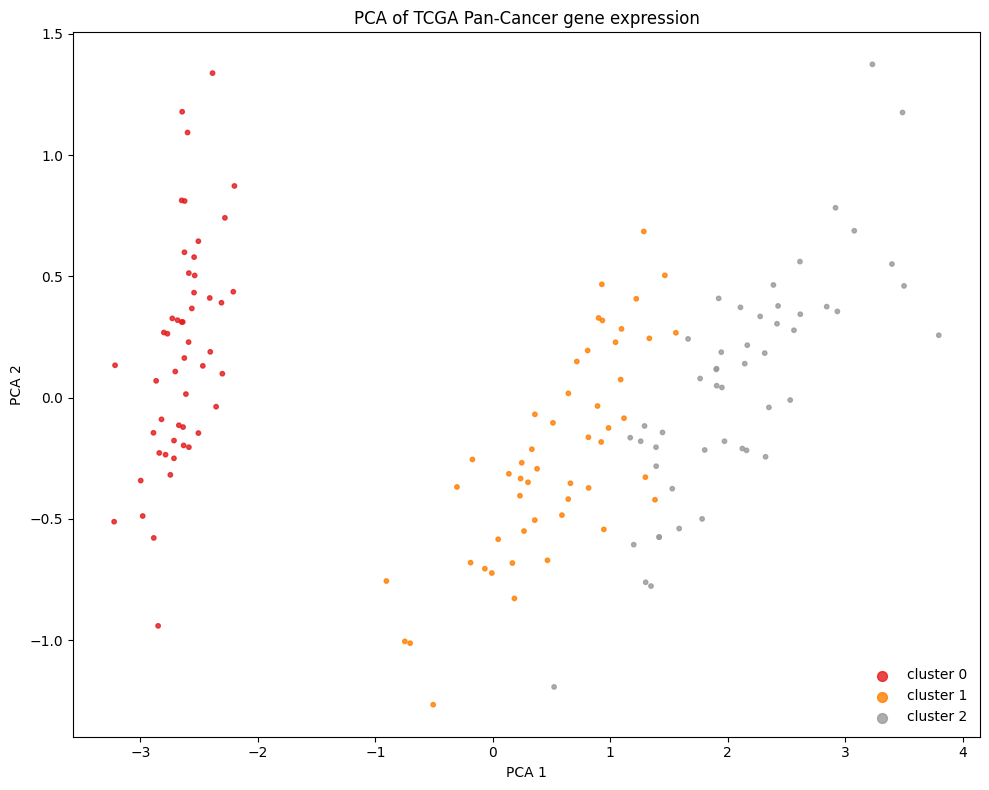

In [45]:
plot_dim_reduced_clustering(X, y, method='PCA')

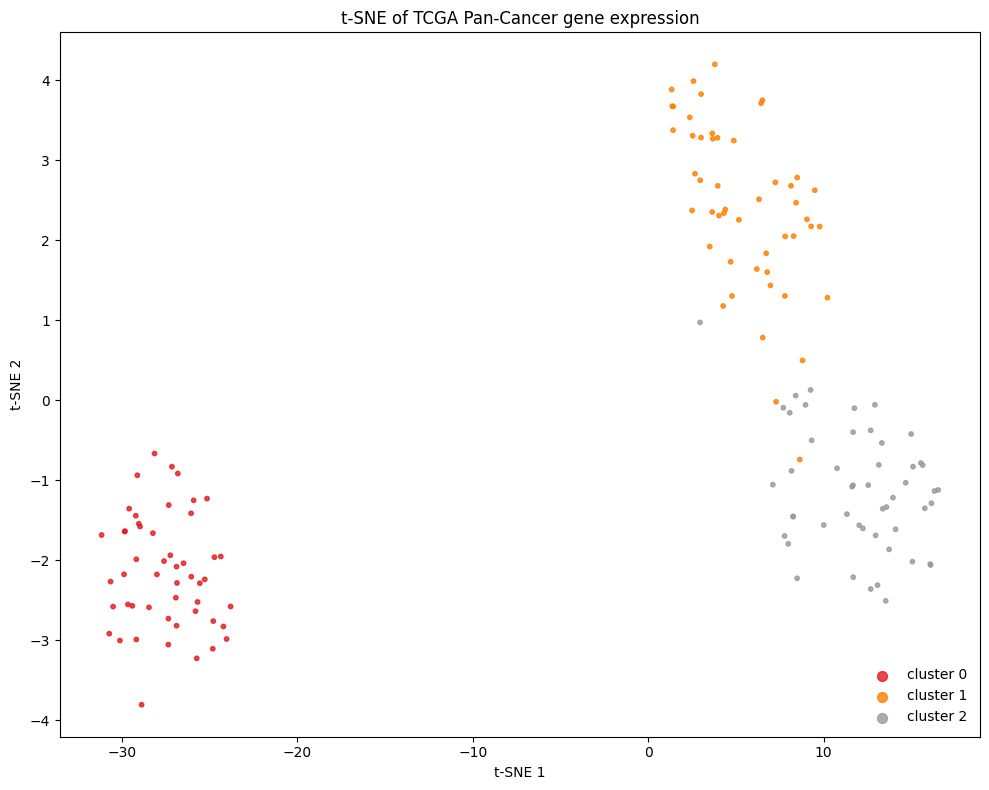

In [46]:
plot_dim_reduced_clustering(X, y, method='tSNE')

/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


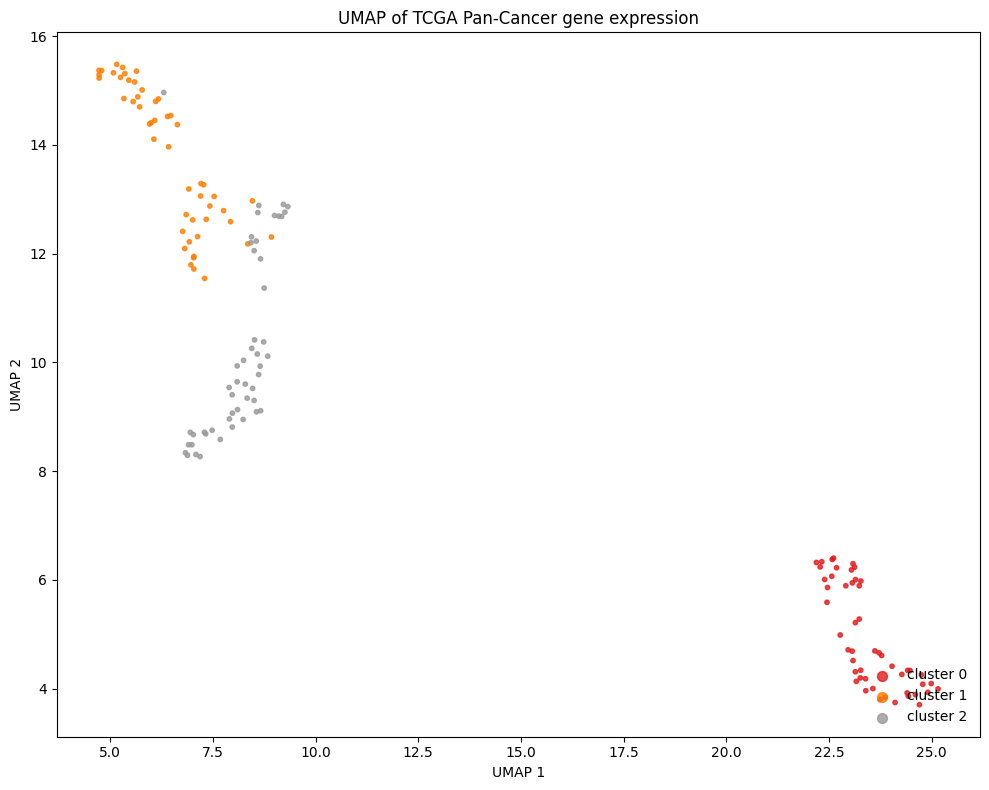

In [47]:
plot_dim_reduced_clustering(X, y, method='UMAP')

DARMANIS:

In [62]:
# data_dir = Path('./data/DARMANIS')
# data_fp = data_dir / 'GBM_TSNE.csv'
# labels_fp = data_dir / 'GBM_metadata.csv'

# X = pd.read_csv(data_fp, sep=' ', index_col=0)
# y = pd.read_csv(labels_fp, sep=' ', index_col=0)['Sample.type']

# print("X shape:", X.shape, " |  y shape:", y.shape)

X shape: (3589, 2)  |  y shape: (3589,)


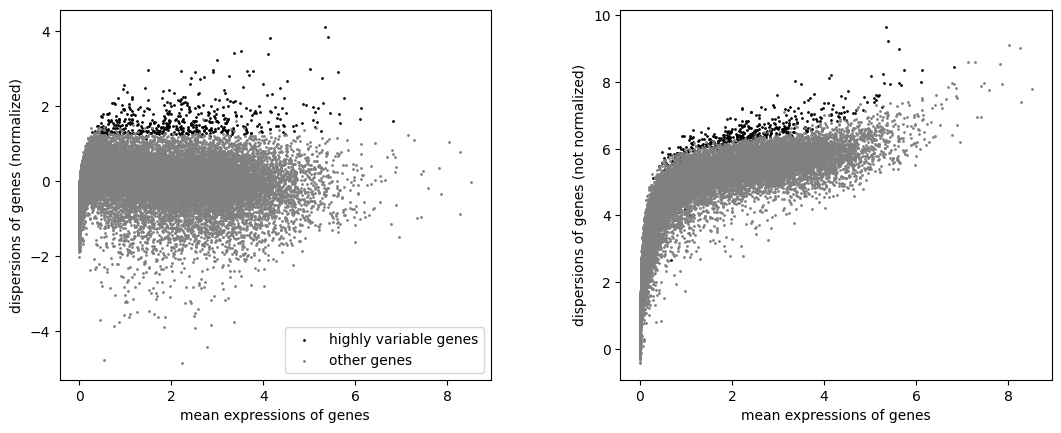

X shape: (3589, 500)


In [122]:
adata = ad.read_h5ad('data/DARMANIS/darmanis_fromraw.h5ad')

sc.pp.highly_variable_genes(adata, n_top_genes=500, batch_key="Sample.name", flavor='seurat')
sc.pl.highly_variable_genes(adata)

adata_hvg = adata[:, adata.var['highly_variable']]
X = adata_hvg.X

# print("X shape:", X.shape, " |  y shape:", y.shape)
print("X shape:", X.shape)

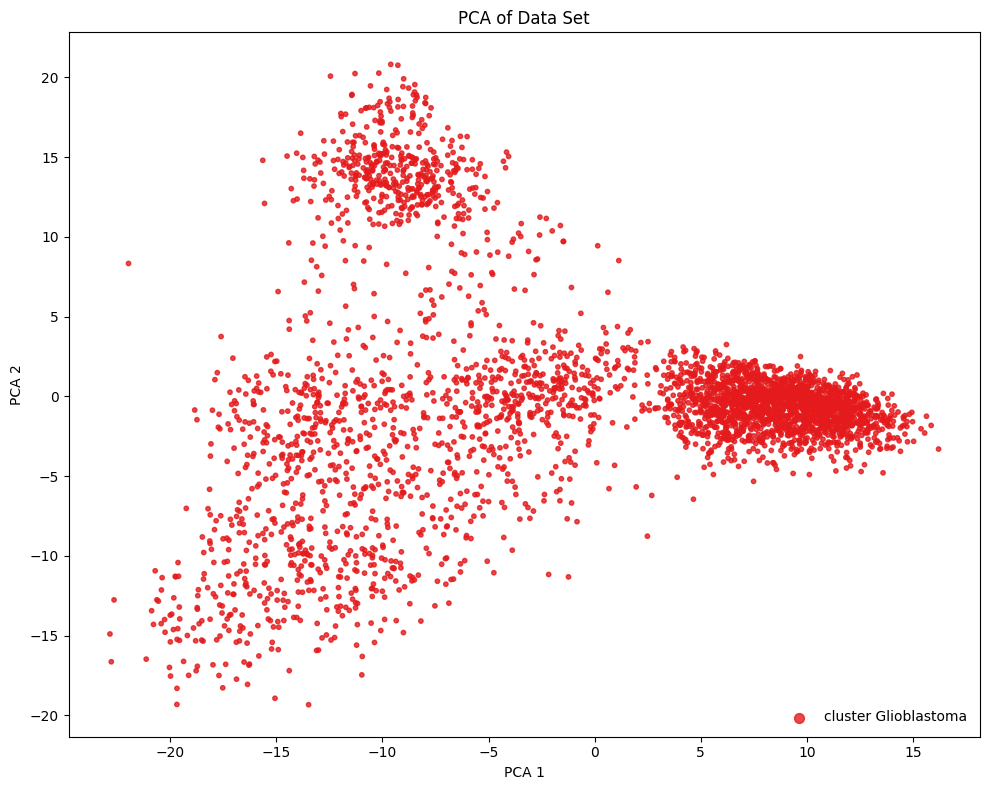

In [123]:
plot_dim_reduced_clustering(X, y, method='PCA')

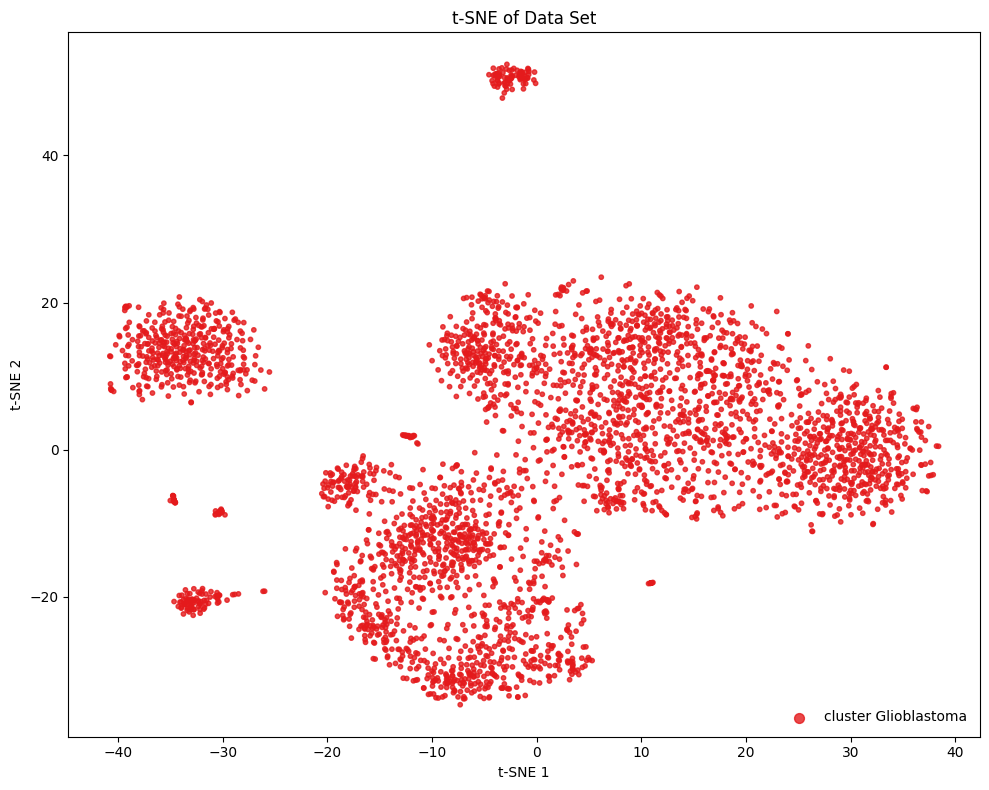

In [124]:
plot_dim_reduced_clustering(X, y, method='tSNE')

/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


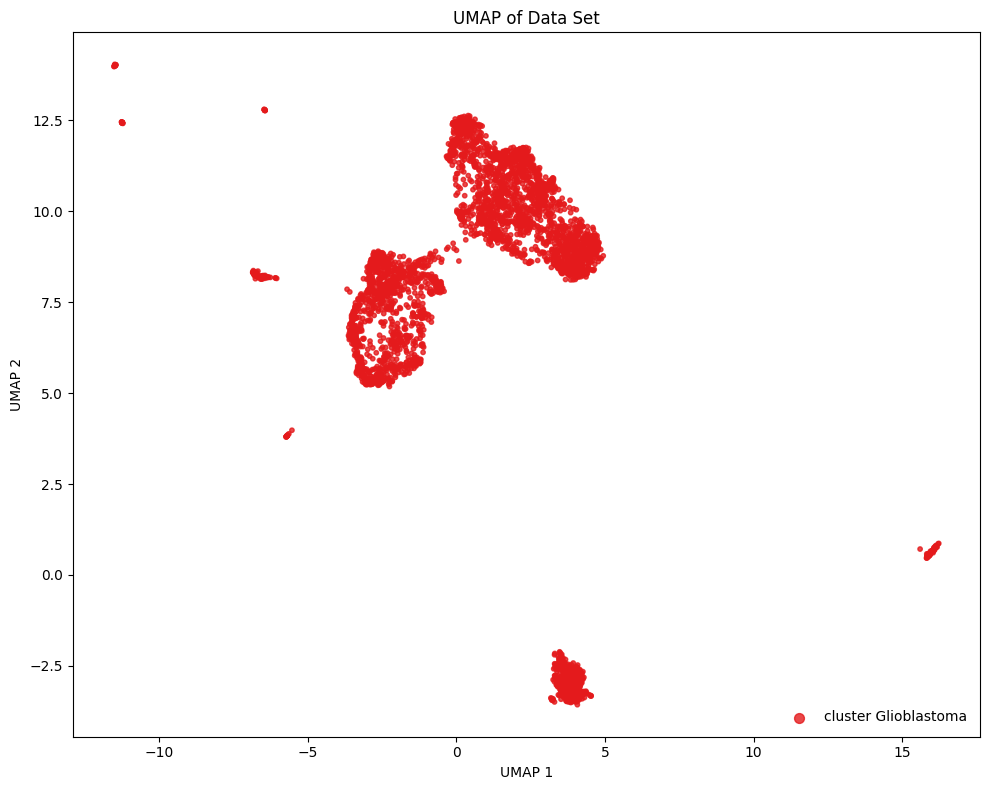

In [125]:
plot_dim_reduced_clustering(X, y, method='UMAP')

---

## 1. Cluster Analysis with Resampling for Validation and Exploration (CARVE) Algorithm:

In [66]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


In utils.py:

In [67]:
def get_preprocessing(
    normalization_method: str = 'normal',
    dim_red_method: str = 'PCA', 
    n_components: int = 50, 
    perplexity: int = 30, 
    n_neighbors: int = 15, 
    min_dist: float = 0.1
) -> Pipeline:
    """
    perform data normalization and dimensionality reduction.

    :param normalization_method: normalization method to be applied; one of 'raw', 'normal', or 'l1p'
    :param dim_red_method: dimensionality reduction technique to use; one of 'raw', 'PCA', 'tSNE', or 'UMAP'
    :param n_components: target number of components for dimensionality reduction
    :param perplexity: perplexity parameter for t-SNE (only if dim_red_method == 'tSNE')
    :param n_neighbors: number of neighbors for UMAP (only if dim_red_method == 'UMAP')
    :param min_dist: minimum distance between points in UMAP embedding (only if dim_red_method == 'UMAP')

    :return: sklearn Pipeline object
    """
    steps = []
    # normalization
    if normalization_method == 'raw':
        steps.append(('norm', FunctionTransformer(lambda X: X)))
    elif normalization_method == 'normal':
        steps.append(('norm', StandardScaler()))
    elif normalization_method == 'l1p':
        steps.append(('norm', FunctionTransformer(np.log1p)))
    # dim reduction
    if dim_red_method == 'raw':
        steps.append(('dr', FunctionTransformer(lambda X: X)))
    elif dim_red_method == 'PCA':
        steps.append(('dr', PCA(n_components=n_components, random_state=RANDOM_SEED)))
    elif dim_red_method == 'tSNE':
        steps.append(('dr', TSNE(n_components=n_components, perplexity=perplexity, random_state=RANDOM_SEED)))
    elif dim_red_method == 'UMAP':
        steps.append(('dr', UMAP(n_components=n_components, n_neighbors=n_neighbors, min_dist=min_dist, random_state=RANDOM_SEED)))
        
    return Pipeline(steps)

def clustering_pipeline(
    X: np.ndarray,
    estimator: Type[ClusterMixin],
    **params
) -> np.ndarray:
    """
    Cluster data using a scikit-learn estimator and parameter dict.

    :param X: data array of shape (n_samples, n_features)
    :param estimator: clustering class implementing fit_predict (e.g. KMeans)
    :param params: hyperparameters for the estimator
    
    :return: cluster labels array
    """
    
    model = estimator(**params)
    return model.fit_predict(X)

In [ ]:
@dataclass
class ClusteringValidator:
    """
    Validate clustering stability and generalizability across estimator grids.

    :param X: input data, shape (n_samples, n_features)
    :param grids: list of tuples (estimator_class, param_grid)
    :param B: number of bootstrap iterations per config
    :param rho: subsampling ratio for splits
    :param num_cores: parallel jobs count
    """
    X: np.ndarray
    K: int = 10
    model_grids: Optional[list[tuple[Type[ClusterMixin], dict[str, list[Any]]]]] = None
    norm_options: Optional[
        list[tuple[Callable[..., TransformerMixin], dict[str, list[Any]]]]
    ] = None
    dr_options: Optional[
        list[tuple[Callable[..., TransformerMixin], dict[str, list[Any]]]]
    ] = None
    B: int = 20
    rho: float = 0.8
    num_cores: int = field(default_factory=lambda: max(1, multiprocessing.cpu_count() - 1))

    def __post_init__(self):
        """
        Initialize default grids if none provided.
        """
        # ensure X is an ndarray so that X[integer_array] slices rows
        if isinstance(self.X, pd.DataFrame):
            self.X = self.X.values
            
        if self.model_grids is None:
            D2 = pairwise_distances(self.X, metric='sqeuclidean')
            median_d2 = np.median(D2[np.triu_indices_from(D2, k=1)])
            gamma0 = 1.0 / (2.0 * median_d2)

            self.model_grids = [
                (KMeans, {'n_clusters': list(range(2, self.K+1))}),
                (AgglomerativeClustering, {'n_clusters': list(range(2, self.K+1)), 'linkage': ['ward','complete','average','single']}),
                (SpectralClustering, {'n_clusters': list(range(2, self.K+1)), 'gamma': list(np.logspace(np.log10(gamma0)-1, np.log10(gamma0)+1, num=4))})
            ]
        
        if self.norm_options is None or self.dr_options is None:
            n_samples, p = self.X.shape
            min_n = int(round(n_samples * (1 - self.rho))) - 1
            
            # default normalization choices
            self.norm_options = [
                (FunctionTransformer, {}),  # identity
                (StandardScaler, {}),  # zero-mean/unit-var
                (FunctionTransformer, {'func': [np.log1p]})  # log1p
            ]

            # default dimensionality-reduction choices
            self.dr_options = [
                (FunctionTransformer, {}),  # no DR
                (PCA, {'n_components': list(range(2, min(min_n, p) + 1))}),
                (TSNE, {'n_components': [2, 3], 'perplexity': list(range(5, min_n))}),
                (UMAP, {'n_components': list(range(2, min(min_n, p) + 1)), 'n_neighbors': list(range(5, 51)), 'min_dist': [0.1]}),
            ]
    
    def _draw_random_pipeline(self, seed: int) -> tuple[Pipeline, dict[str, Any], dict[str, Any]]:
        """
        randomly choose one preprocessing spec (norm + dr),
        sample a hyperparam combo from each grid,
        instantiate and return a Pipeline, plus the raw param dicts.

        :param seed: Seed for the random number generator to ensure reproducibility.

        :return: pipeline, norm_params, dr_params
        """        
        rnd = random.Random(seed)
        norm_factory, norm_grid = rnd.choice(self.norm_options)
        dr_factory, dr_grid = rnd.choice(self.dr_options)
        
        norm_params = {key: rnd.choice(values) for key, values in norm_grid.items()}
        dr_params = {key: rnd.choice(values) for key, values in dr_grid.items()}
        
        norm = norm_factory(**norm_params)
        dr = dr_factory(**dr_params)
        
        pipeline = Pipeline([
            ('norm', norm),
            ('dr', dr)
        ])

        return pipeline, norm_params, dr_params
    
    def _build_consensus_matrix(self, runs: list[tuple[np.ndarray, np.ndarray]]) -> sparse.csr_matrix:
        """
        given a list of length-B label arrays and sampling numbers,
        build a sparse co-association matrix and return it normalized.
        
        :param runs: list of (idx, labels_sub) for each of B bootstraps
        
        :return: an n x n consensus matrix
        """
        n = self.X.shape[0]
        co = sparse.csr_matrix((n, n), dtype=float)
        counts = sparse.csr_matrix((n, n), dtype=float)

        # accumulate co‐association & counts
        for idx, labels in runs:
            u = sparse.csr_matrix((np.ones_like(idx), (idx, np.zeros_like(idx))), shape=(n, 1))
            counts += u.dot(u.T)
            uniq, inv = np.unique(labels, return_inverse=True)
            L = sparse.csr_matrix((np.ones_like(idx), (idx, inv)), shape=(n, uniq.size))
            co += L.dot(L.T)

        counts.data = 1.0 / counts.data
        consensus = co.multiply(counts).toarray()  # full n×n matrix

        # seriation via average‐linkage dendrogram
        # 1) distances = 1 − consensus similarity  
        dists = squareform(1.0 - consensus, checks=False)
        Z = linkage(dists, method='average')
        order = leaves_list(Z)

        # reorder rows & cols
        C_ord = consensus[order][:, order]
        return sparse.csr_matrix(C_ord)
    
    def _build_misclassification_arr(self, runs: list[tuple[np.ndarray, np.ndarray]]) -> np.ndarray:
        """
        given a list of length-B predicted label arrays, true label arrays, and sampling numbers,
        build an array of misclassification rate for each sample (# correctly classified/# present in test set).
        
        :param runs: list of (idx, labels_pred, labels_true) for each of B bootstraps
        
        :return: an array of length n with misclassification rates for each sample
        """
        n = self.X.shape[0]
        correct_count = np.zeros(n, dtype=int)
        total_count = np.zeros(n, dtype=int)
        
        for idx, labels_test, labels_pred in runs:
            is_correct = (labels_test == labels_pred)
            
            np.add.at(correct_count, idx, is_correct.astype(int))
            np.add.at(total_count, idx, 1)
        
        valid = total_count > 0
        misclass = np.ones(n, dtype=float)
        misclass[valid] = 1.0 - (correct_count[valid] / total_count[valid])
        
        return misclass

    def _validation_iter(
        self,
        est_class: Type[ClusterMixin],
        params: dict[str, Any],
        seed: int, 
        random_preproc: bool = True
    ) -> tuple[float, float]:
        """
        Perform single iteration of clustering, and ARI evaluation.

        :param est_class: clustering estimator class
        :param params: estimator hyperparameters
        :param seed: random seed for reproducibility
        :param random_preproc: indicates whether to perform the full workflow process (random pre-processing)
        
        :return: (model-explorer ARI, predictive ARI)
        """
        # subsample indices
        n_samples = self.X.shape[0]
        A_train_idx, A_test_idx = subsample_indices(n_samples, self.rho, seed)
        B_idx, _ = subsample_indices(n_samples, self.rho, seed + self.B)
        
        # build preprocessing pipeline
        if random_preproc:
            pipeline, norm_params, dr_params = self._draw_random_pipeline(seed)
        else:
            pipeline = Pipeline([('identity', FunctionTransformer(lambda X: X))])
            norm_params = dr_params = {}

        X1 = pipeline.fit_transform(self.X[A_train_idx])
        X_test = pipeline.fit_transform(self.X[A_test_idx])
        X2 = pipeline.fit_transform(self.X[B_idx])
        
        # clustering directly
        labels1 = clustering_pipeline(X1, est_class, **params)
        labels_test = clustering_pipeline(X_test, est_class, **params)
        labels2 = clustering_pipeline(X2, est_class, **params)
        
        # model-explorer ARI
        _, i1, i3 = np.intersect1d(A_train_idx, B_idx, return_indices=True)
        ari1 = adjusted_rand_score(labels1[i1], labels2[i3])
        
        # predictive ARI
        rf = RandomForestClassifier(
            n_estimators=100, 
            max_depth=self.X.shape[1],
            max_features=int(np.sqrt(self.X.shape[1])),
            random_state=seed
        )
        rf.fit(self.X[A_train_idx], labels1)
        pred = rf.predict(self.X[A_test_idx])
        ari2 = adjusted_rand_score(labels_test, pred)
        
        return ari1, ari2, labels1, A_train_idx, labels_test, pred, A_test_idx, norm_params, dr_params

    def fit(self, random_preproc: bool = False) -> pd.DataFrame:
        """
        Run validation across all estimators and parameter grids.
        
        :param random_preproc: indicates whether to perform the full workflow process (random pre-processing)

        :return: DataFrame with columns ['estimator', *param_keys, 'ari_model_explorer', 'ari_predictive']
        """
        total = sum(len(list(ParameterGrid(grid))) for _, grid in self.model_grids)
        
        records_method = []
        pipeline_chunks = []
        cons_arr = []
        misclass_arr = []
        
        with tqdm(total=total, desc="Grid configs") as pbar:
            for est_class, grid in self.model_grids:
                for params in ParameterGrid(grid):
                    worker = delayed(self._validation_iter)
                    
                    results = Parallel(n_jobs=self.num_cores)(
                        worker(est_class, params, b, random_preproc) for b in range(self.B)
                    )
                    aris1, aris2, labels1, idx, labels_test, labels_pred, idx_test, _, _ = zip(*results)
                    
                    # consensus matrix
                    C = self._build_consensus_matrix(zip(idx, labels1))
                    cons_arr.append(C)
                    
                    # misclassification array
                    M = self._build_misclassification_arr(zip(idx_test, labels_test, labels_pred))
                    misclass_arr.append(M)
                
                    # method‐level
                    records_method.append({
                        'estimator': est_class.__name__,
                        **params,
                        'ari_model_explorer': np.mean(aris1),
                        'ari_predictive': np.mean(aris2)
                    })
                    
                    # pipeline‐level
                    if random_preproc:
                        df_chunk = pd.DataFrame(results, 
                            columns=['ari_model_explorer', 'ari_predictive', 'labels1', 'idx', 'labels_test', 'labels_pred', 'idx_test', 'norm', 'dr']
                        )
                        df_chunk.drop(['labels1', 'idx', 'labels_test', 'labels_pred', 'idx_test'], axis=1, inplace=True)
                        df_chunk['n_clusters'] = params['n_clusters']
                        for key, val in params.items():
                            df_chunk[key] = val
                        pipeline_chunks.append(df_chunk)
                        
                    pbar.update(1)
        
        # by-method df
        self.df_method = pd.DataFrame.from_records(records_method)
        
        # by-pipeline df
        if random_preproc:
            df_pipe_raw = pd.concat(pipeline_chunks, ignore_index=True)
            
            # flatten
            norm_flat = pd.json_normalize(df_pipe_raw['norm']).add_prefix('norm__')
            dr_flat = pd.json_normalize(df_pipe_raw['dr']).add_prefix('dr__')
            
            pipe_df = pd.concat([
                df_pipe_raw.drop(['norm', 'dr'], axis=1), 
                norm_flat, 
                dr_flat
            ], axis=1)
            
            flat_norm_cols = list(norm_flat.columns)
            flat_dr_cols = list(dr_flat.columns)
            other_cols = ['n_clusters', *[k for k in self.model_grids[0][1].keys() if k!='n_clusters']]
            group_cols = flat_norm_cols + flat_dr_cols + other_cols
            
            self.df_pipeline = (
                pipe_df
                .groupby(group_cols, as_index=False)
                .agg({'ari_model_explorer': 'mean', 'ari_predictive': 'mean'})
            )
        else:
            self.df_pipeline = None
            
        # consensus matrices
        self.consensus_matrices = cons_arr
            
        # misclassification array
        self.misclassification_arrays = misclass_arr
        
        # plot stability plots
        self.plot_results()

        return self.df_method
    
    def plot_results(
        self,
        measure: str = 'stability'
    ) -> None:
        """
        Plot clustering stability or generalizability across methods and pipelines.

        :param measure: 'stability' for model-explorer ARI, 'generalizability' for predictive ARI
        """
        # select metric
        if measure == 'stability':
            col = 'ari_model_explorer'
            ylabel = 'Stability (ARI)'
            title_m = 'Stability per clustering method'
            title_p = 'Stability per pipeline'
        else:
            col = 'ari_predictive'
            ylabel = 'Generalizability (ARI)'
            title_m = 'Generalizability per clustering method'
            title_p = 'Generalizability per pipeline'

        # setup axes
        has_pipe = self.df_pipeline is not None
        if has_pipe:
            fig, (axm, axp) = plt.subplots(1, 2, figsize=(20, 8))
        else:
            fig, axm = plt.subplots(1, 1, figsize=(10, 8))
            axp = None

        # plot methods
        for est in self.df_method['estimator'].unique():
            df_est = self.df_method[self.df_method['estimator'] == est]

            # pick only relevant hyper‐params
            param_cols = [
                c for c in df_est.columns 
                if c not in ['estimator', 'n_clusters', 'ari_model_explorer', 'ari_predictive']
                and not df_est[c].isna().all()
            ]

            # if param_cols is empty, treat df_est as single group
            if param_cols:
                groups = df_est.groupby(param_cols, dropna=False)
            else:
                groups = [(None, df_est)]

            for _, grp in groups:
                grp_sorted = grp.sort_values('n_clusters')
                row = grp_sorted.iloc[0]

                parts = [
                    f"{k}={row[k]}" 
                    for k in param_cols 
                    if pd.notna(row[k])
                ]
                params_str = ", ".join(parts)
                label = f"{est} ({params_str})" if params_str else est

                axm.plot(
                    grp_sorted['n_clusters'],
                    grp_sorted[col],
                    marker='o',
                    label=label
                )
                
        axm.set_xlabel('n_clusters')
        axm.set_ylabel(ylabel)
        axm.set_title(title_m)
        axm.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

        # plot pipelines
        if has_pipe:
            df_pipe = self.df_pipeline
            for _, grp in df_pipe.groupby(['norm', 'dr'], dropna=False):
                grp_sorted = grp.sort_values('n_clusters')
                label = f"{grp_sorted.iloc[0]['norm']}+{grp_sorted.iloc[0]['dr']}"
                axp.plot(
                    grp_sorted['n_clusters'],
                    grp_sorted[col],
                    marker='o',
                    alpha=0.7,
                    label=label
                )
                
            axp.set_xlabel('n_clusters')
            axp.set_ylabel(ylabel)
            axp.set_title(title_p)
            axp.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

        plt.tight_layout()
        plt.show()

    def plot_cons_matrix(self) -> None:
        """
        Display consensus matrices for best stability and predictive configurations.
        """
        # get best indices
        idx_me = self.df_method['ari_model_explorer'].idxmax()
        idx_pr = self.df_method['ari_predictive'].idxmax()

        # retrieve consensus matrices and best parameter records
        C_me = self.consensus_matrices[idx_me]
        C_pr = self.consensus_matrices[idx_pr]
        best_me = self.df_method.iloc[idx_me]
        best_pr = self.df_method.iloc[idx_pr]

        # plotting
        fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)
        for ax, (C, title, row) in zip(
            axes,
            [
                (C_me, 'Most stable model', best_me),
                (C_pr, 'Most generalizable model', best_pr)
            ]
        ):
            im = ax.imshow(C.toarray(), vmin=0, vmax=1)
            params = [
                f"{k}={row[k]}" for k in row.index
                if k not in ['estimator', 'ari_model_explorer', 'ari_predictive']
                and pd.notna(row[k])
            ]
            
            param_str = ", ".join(params)
            ax.set_title(f"{title}\n{row['estimator']} | {param_str}")
            ax.axis('off')

        # add colorbar
        fig.colorbar(
            im,
            ax=axes,
            orientation='vertical',
            fraction=0.04,
            pad=0.02
        )
        
        plt.show()
        
    def plot_final_clustering(
        self,
        measure: str = 'stability',
        min_alpha: float = 0.2,
        max_alpha: float = 0.9,
        min_size: float = 10,
        max_size: float = 100
    ) -> None:
        """
        Final PCA scatter where size proportional to sample certainty and opacity proportional cluster certainty,
        plus boxplots of per-sample variances for each cluster.
        
        :param measure: 'stability' for model-explorer ARI, 'generalizability' for predictive ARI
        """
        # choose metric
        col = 'ari_model_explorer' if measure == 'stability' else 'ari_predictive'
        best_idx = self.df_method[col].idxmax()
        best_method = self.df_method.loc[best_idx]

        # optional pipeline
        # if self.df_pipeline is not None:
        #     best_pipe_idx = self.df_pipeline[col].idxmax()
        #     proc = get_preprocessing(
        #         self.df_pipeline.loc[best_pipe_idx, 'norm'],
        #         self.df_pipeline.loc[best_pipe_idx, 'dr']
        #     )
        #     X_proc = proc.fit_transform(self.X)
        # else:
        #     X_proc = self.X.copy()
        X_proc = self.X.copy()

        # get estimator class & valid params
        est_name = best_method['estimator']
        est_class, grid = next(
            (c, g) for c, g in self.model_grids if c.__name__ == est_name
        )
        valid_params = grid.keys()

        # pull only valid, non-NaN params
        params = {
            k: best_method[k]
            for k in valid_params
            if pd.notna(best_method.get(k))
        }

        # run clustering on full data
        labels = clustering_pipeline(X_proc, est_class, **params)

        # compute consensus-based variances
        C = self.consensus_matrices[best_idx].toarray()
        P = C / C.sum(axis=1, keepdims=True)
        variances = np.var(P, axis=1)

        # PCA embedding for scatter
        coords = PCA(n_components=2, random_state=0).fit_transform(self.X)

        # compute per-cluster variances for boxplot
        clusters = np.unique(labels)
        cluster_vars = [variances[labels == cl] for cl in clusters]

        # sizes & opacities
        v_min, v_max = variances.min(), variances.max()
        v_norm = (variances - v_min) / (v_max - v_min) if v_max > v_min else np.zeros_like(variances)
        sizes = (1 - v_norm) * (max_size - min_size) + min_size

        cluster_variance = pd.Series({cl: variances[labels == cl].mean() for cl in clusters})
        cv_min, cv_max = cluster_variance.min(), cluster_variance.max()
        cv_norm = (cluster_variance - cv_min) / (cv_max - cv_min) if cv_max > cv_min else pd.Series(0, index=cluster_variance.index)
        alpha_raw = 1 - cv_norm
        alpha_clamped = alpha_raw * (max_alpha - min_alpha) + min_alpha

        # build param string
        param_str = ", ".join(f"{k}={v}" for k, v in params.items())
        title = f"{est_name} | {param_str}" if param_str else est_name

        # setup figure with two panels
        fig, (ax_scatter, ax_box) = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)

        # scatter plot
        cmap = plt.get_cmap('tab10')
        for i, cl in enumerate(clusters):
            mask = labels == cl
            ax_scatter.scatter(
                coords[mask, 0], coords[mask, 1],
                s=sizes[mask],
                alpha=float(alpha_clamped.loc[cl]),
                color=cmap(i),
                label=f'cluster {cl}'
            )
        ax_scatter.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
        ax_scatter.set_title(title)
        ax_scatter.axis('off')

        # boxplot of variances per cluster
        ax_box.boxplot(cluster_vars, labels=[f'cl {cl}' for cl in clusters])
        ax_box.set_xlabel('Cluster')
        ax_box.set_ylabel('Sample-level variance')
        ax_box.set_title('Distribution of sample variances by cluster')

        plt.show()
        
    def plot_misclassification_clustering(
        self,
        measure: str = 'generalizability',
        min_alpha: float = 0.2,
        max_alpha: float = 0.9,
        min_size: float = 10,
        max_size: float = 100
    ) -> None:
        """
        Final PCA scatter where large dots indicate low misclassification (high certainty) and small dots indicate high misclassification (low certainty),
        cluster opacity encodes cluster-average misclassification, and boxplots display per-sample misclassification rates per cluster.

        :param measure: 'stability' uses misclassification from the most stable method (highest model-explorer ARI),
                        otherwise uses misclassification from the most generalizable method (highest predictive ARI).
        """
        # choose best index based on ARI
        if measure == 'stability':
            best_idx = self.df_method['ari_model_explorer'].idxmax()
        else:
            best_idx = self.df_method['ari_predictive'].idxmax()
        best_method = self.df_method.loc[best_idx]

        # sample-level misclassification vector
        M = self.misclassification_arrays[best_idx]

        # determine preprocessing pipeline (if available)
        # if self.df_pipeline is not None and hasattr(self, 'df_pipeline'):
        #     # map measure to correct column name
        #     col = 'ari_model_explorer' if measure == 'stability' else 'ari_predictive'
        #     best_pipe_idx = self.df_pipeline[col].idxmax()
        #     proc = get_preprocessing(
        #         self.df_pipeline.loc[best_pipe_idx, 'norm'],
        #         self.df_pipeline.loc[best_pipe_idx, 'dr']
        #     )
        #     X_proc = proc.fit_transform(self.X)
        # else:
        #     X_proc = self.X.copy()
        X_proc = self.X.copy()

        # clustering estimator and its params
        est_name = best_method['estimator']
        est_class, grid = next(
            (c, g) for c, g in self.model_grids if c.__name__ == est_name
        )
        params = {
            k: best_method[k]
            for k in grid.keys()
            if pd.notna(best_method.get(k))
        }
        param_str = ", ".join(f"{k}={v}" for k, v in params.items())
        title = f"{est_name} | {param_str}" if param_str else est_name

        # run clustering on full data
        labels = clustering_pipeline(X_proc, est_class, **params)

        # compute cluster-average misclassification
        clusters = np.unique(labels)
        cluster_m = np.array([M[labels == cl].mean() for cl in clusters])

        # normalize sample sizes: low misclassification -> large markers
        if M.max() > M.min():
            size_norm = 1.0 - (M - M.min()) / (M.max() - M.min())
        else:
            size_norm = np.ones_like(M)
        sizes = size_norm * (max_size - min_size) + min_size

        # normalize cluster opacities: high misclassification -> lower opacity
        if cluster_m.max() > cluster_m.min():
            cm_norm = 1.0 - (cluster_m - cluster_m.min()) / (cluster_m.max() - cluster_m.min())
        else:
            cm_norm = np.ones_like(cluster_m)
        alpha_vals = cm_norm * (max_alpha - min_alpha) + min_alpha
        alpha_map = dict(zip(clusters, alpha_vals))

        # PCA embedding for scatter
        coords = PCA(n_components=2, random_state=0).fit_transform(self.X)

        # prepare boxplot data
        misclass_by_cluster = [M[labels == cl] for cl in clusters]

        # plotting
        fig, (ax_scatter, ax_box) = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)
        cmap = plt.get_cmap('tab10')
        for i, cl in enumerate(clusters):
            mask = labels == cl
            ax_scatter.scatter(
                coords[mask, 0], coords[mask, 1],
                s=sizes[mask],
                alpha=float(alpha_map[cl]),
                color=cmap(i),
                label=f'cluster {cl}'
            )
        ax_scatter.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
        ax_scatter.set_title(title)
        ax_scatter.axis('off')

        ax_box.boxplot(misclass_by_cluster, labels=[f'cl {cl}' for cl in clusters])
        ax_box.set_xlabel('Cluster')
        ax_box.set_ylabel('Sample misclassification rate')
        ax_box.set_title('Distribution of misclassification by cluster')

        plt.show()

Provide custom grid and models:

In [127]:
# from sklearn.cluster import DBSCAN, Birch

# grids = [
#     (DBSCAN, {'eps': [0.3, 0.5, 0.7], 'min_samples': [5, 10]}),
#     (Birch, {'n_clusters': [2, 3, 4], 'threshold': [0.5, 1.0]})
# ]

# validator = ClusteringValidator(X, grids=grids, B=30, rho=0.8)
# df = validator.fit()

# df

Or run on pre-defined models:

Grid configs:   0%|          | 0/171 [00:00<?, ?it/s]

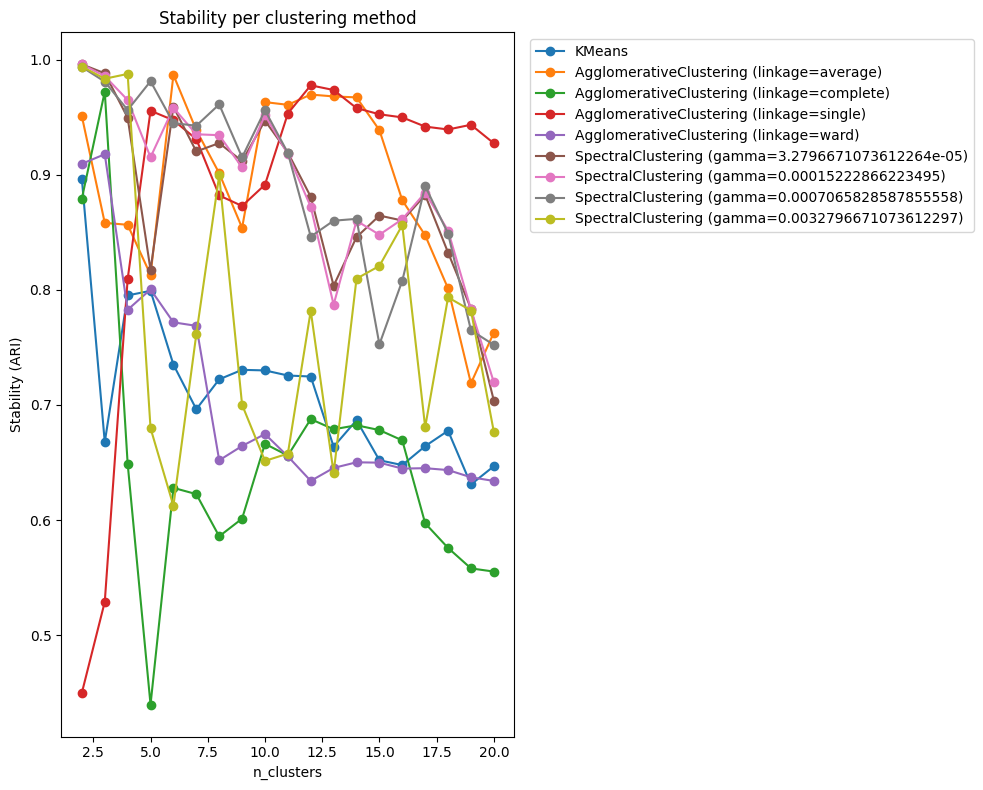

In [128]:
validator = ClusteringValidator(X=X, K=20)
df_method = validator.fit(random_preproc=False)

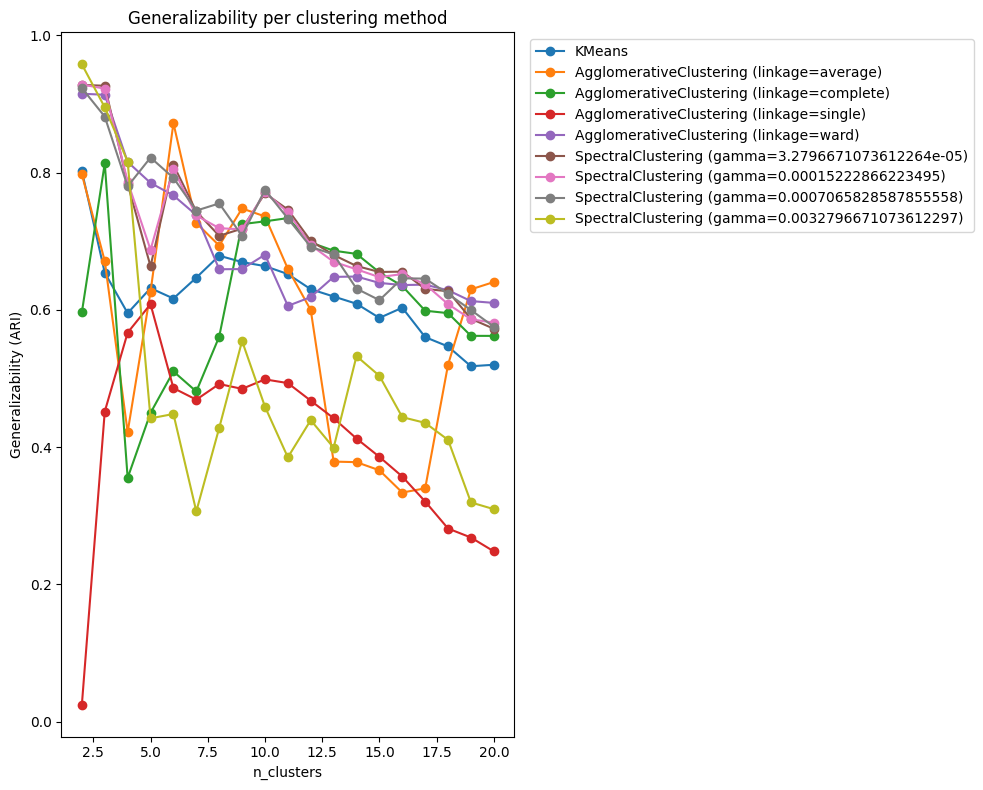

In [129]:
validator.plot_results(measure='generalizability')

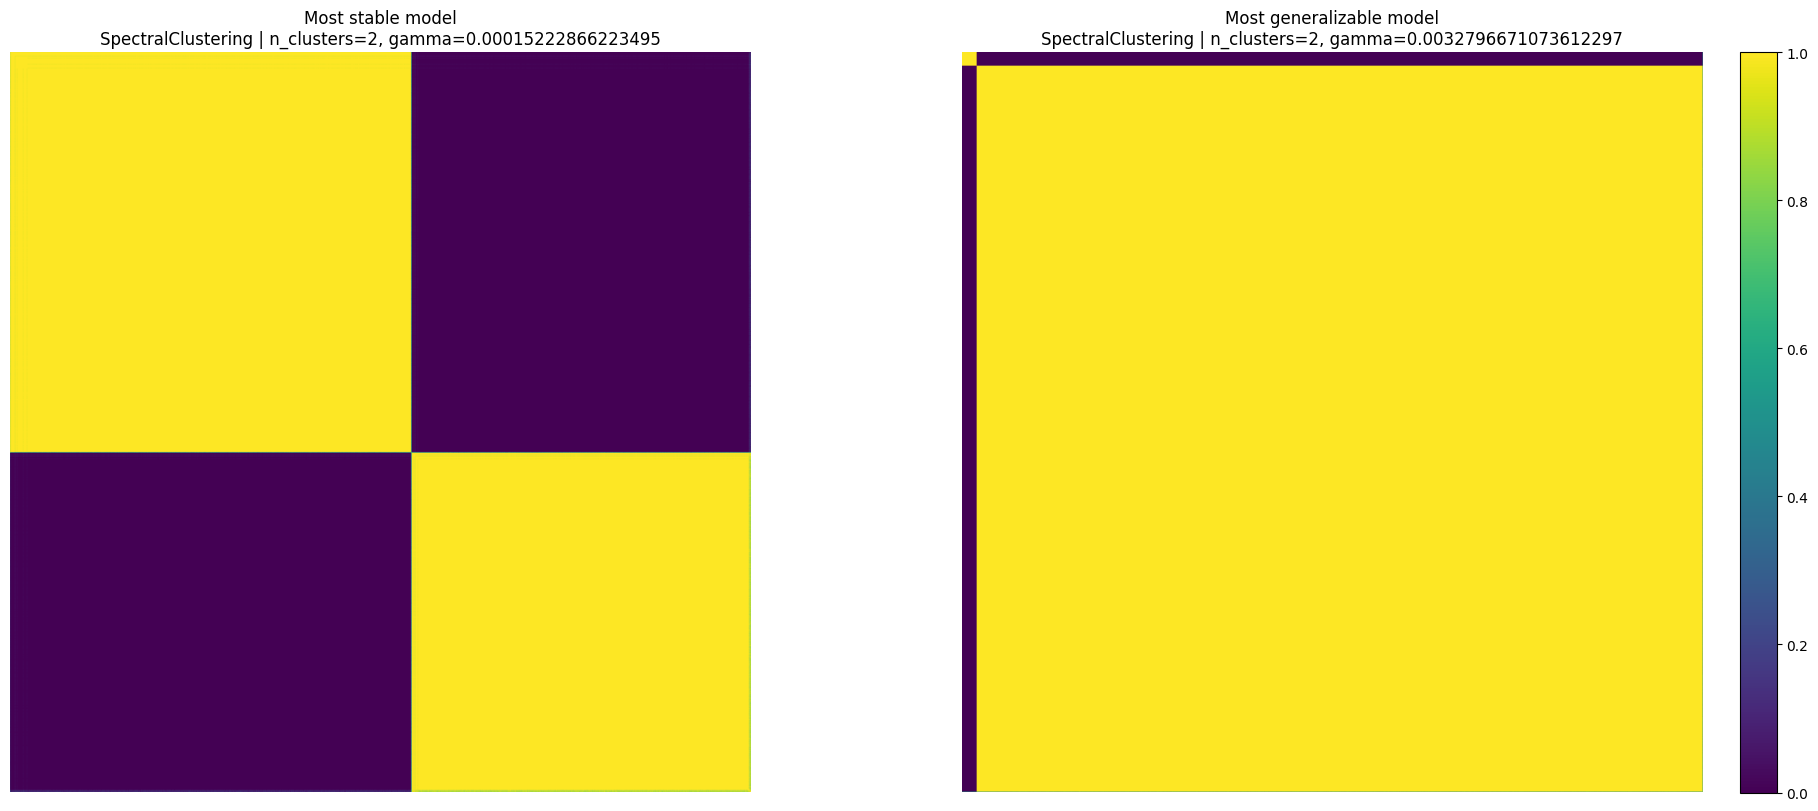

In [130]:
validator.plot_cons_matrix()

/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_8087/130435164.py:529: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_box.boxplot(cluster_vars, labels=[f'cl {cl}' for cl in clusters])


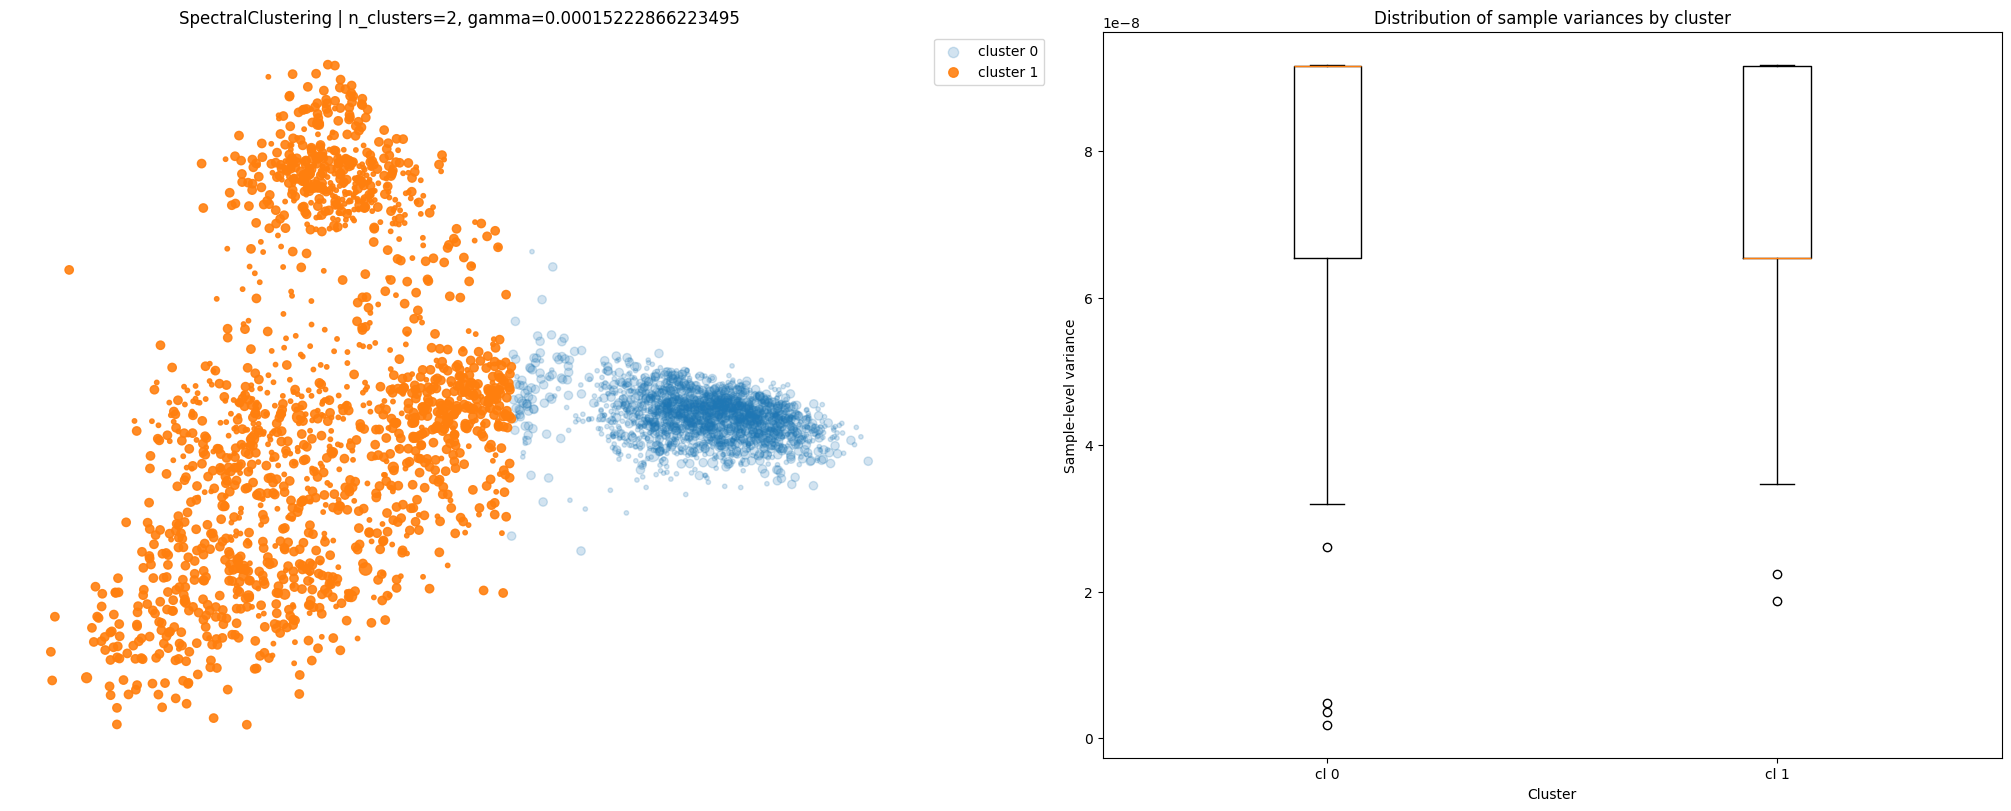

In [131]:
validator.plot_final_clustering(measure='stability')

/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_8087/130435164.py:529: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_box.boxplot(cluster_vars, labels=[f'cl {cl}' for cl in clusters])


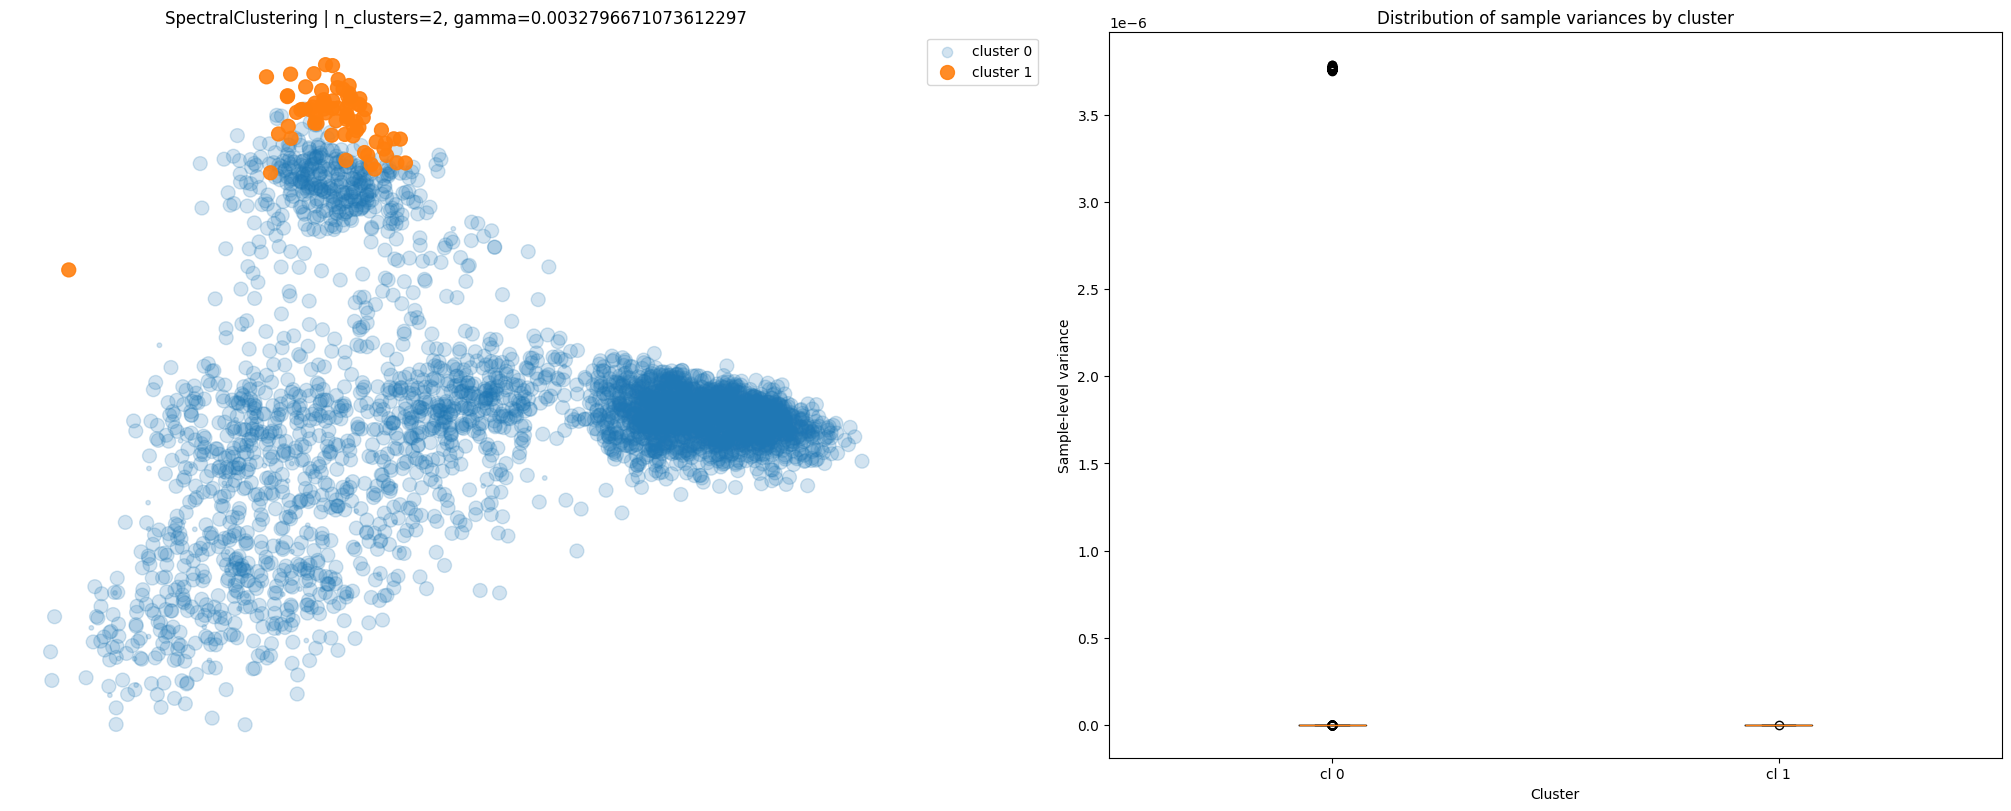

In [132]:
validator.plot_final_clustering(measure='generalizability')

/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_8087/130435164.py:632: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_box.boxplot(misclass_by_cluster, labels=[f'cl {cl}' for cl in clusters])


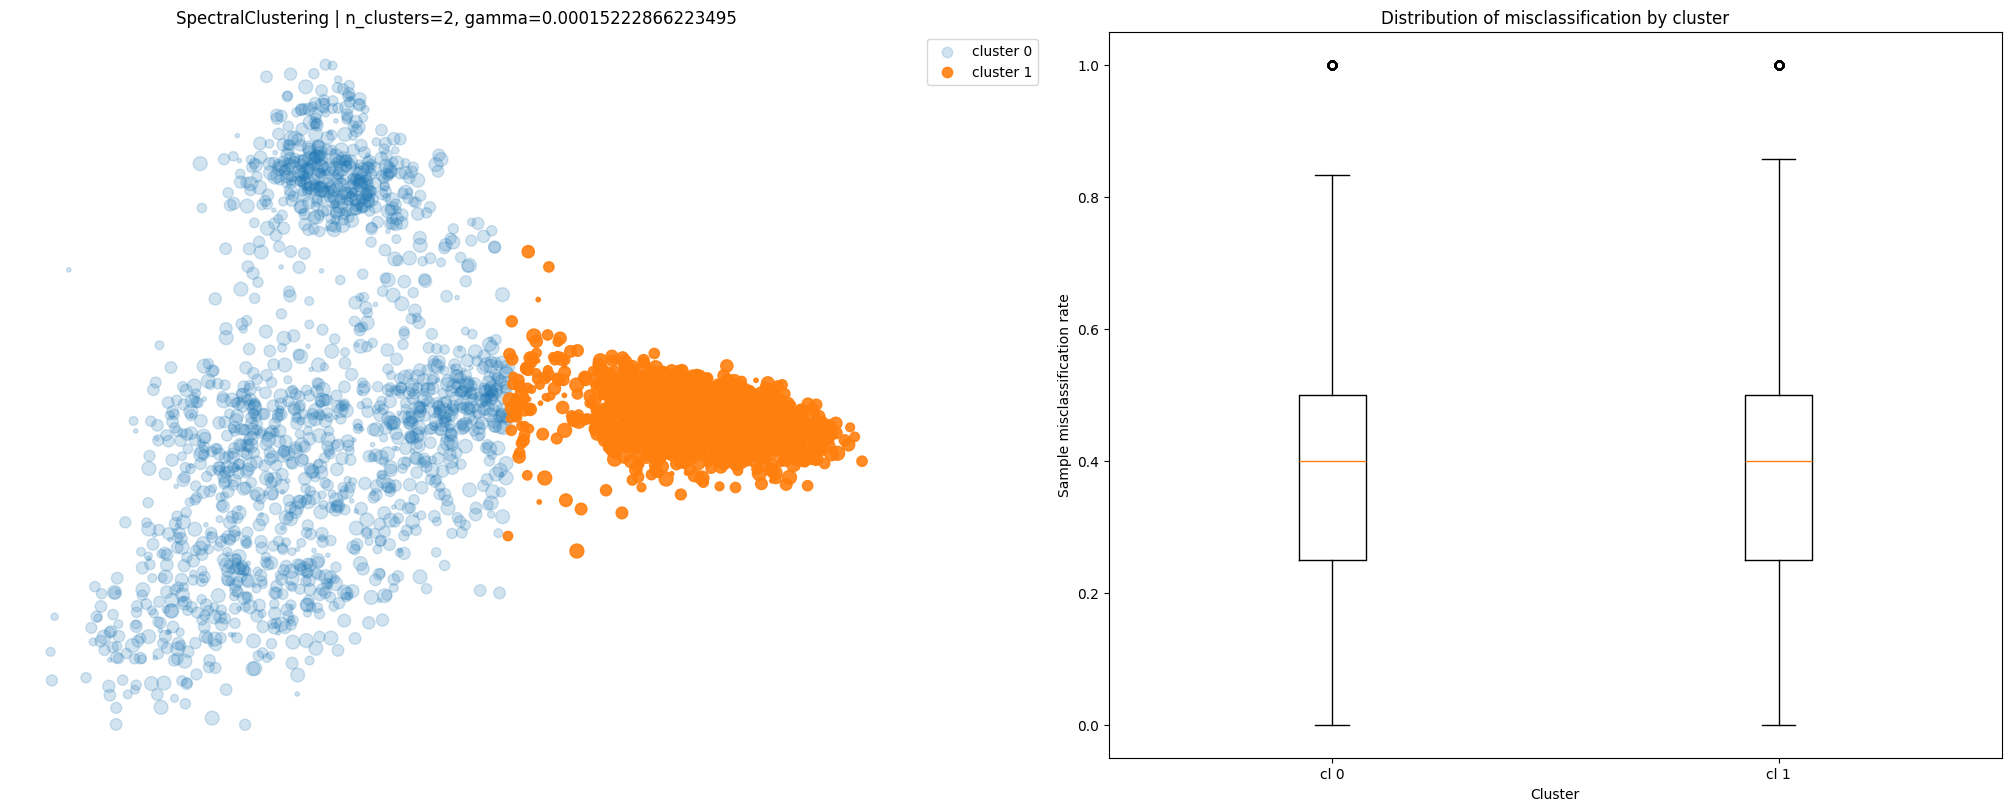

In [133]:
validator.plot_misclassification_clustering(measure='stability')

/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_8087/130435164.py:632: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_box.boxplot(misclass_by_cluster, labels=[f'cl {cl}' for cl in clusters])


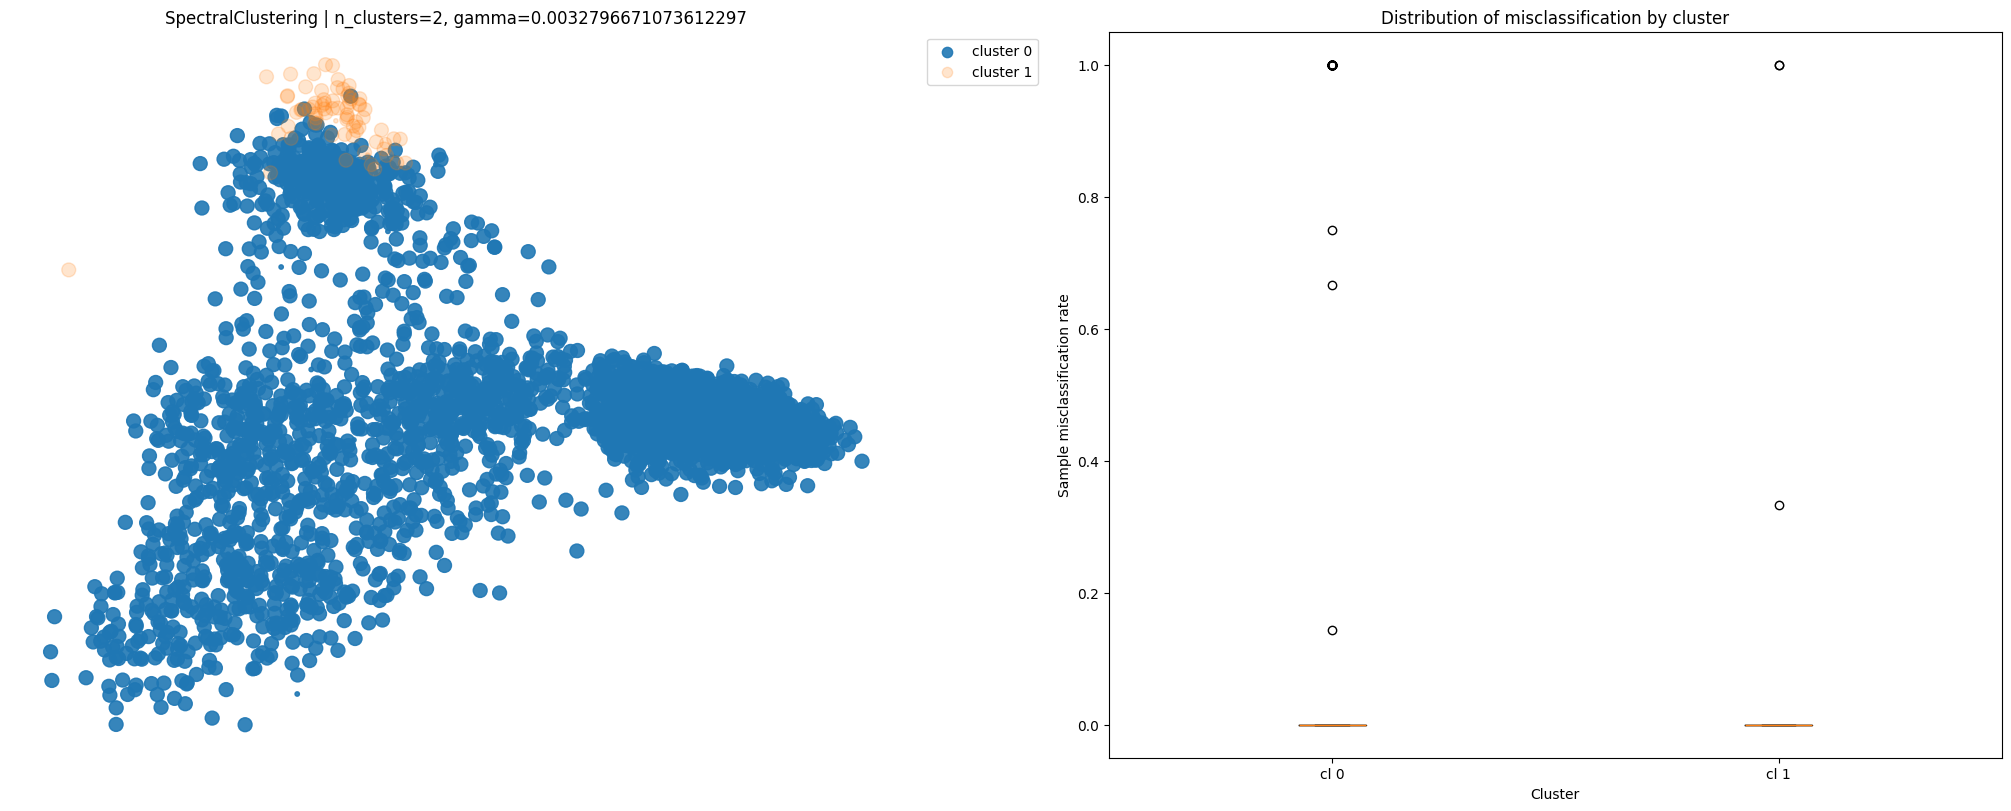

In [134]:
validator.plot_misclassification_clustering(measure='generalizability')

In [135]:
opt_labels = SpectralClustering(n_clusters=2, gamma=0.00015222866223495).fit_predict(X)

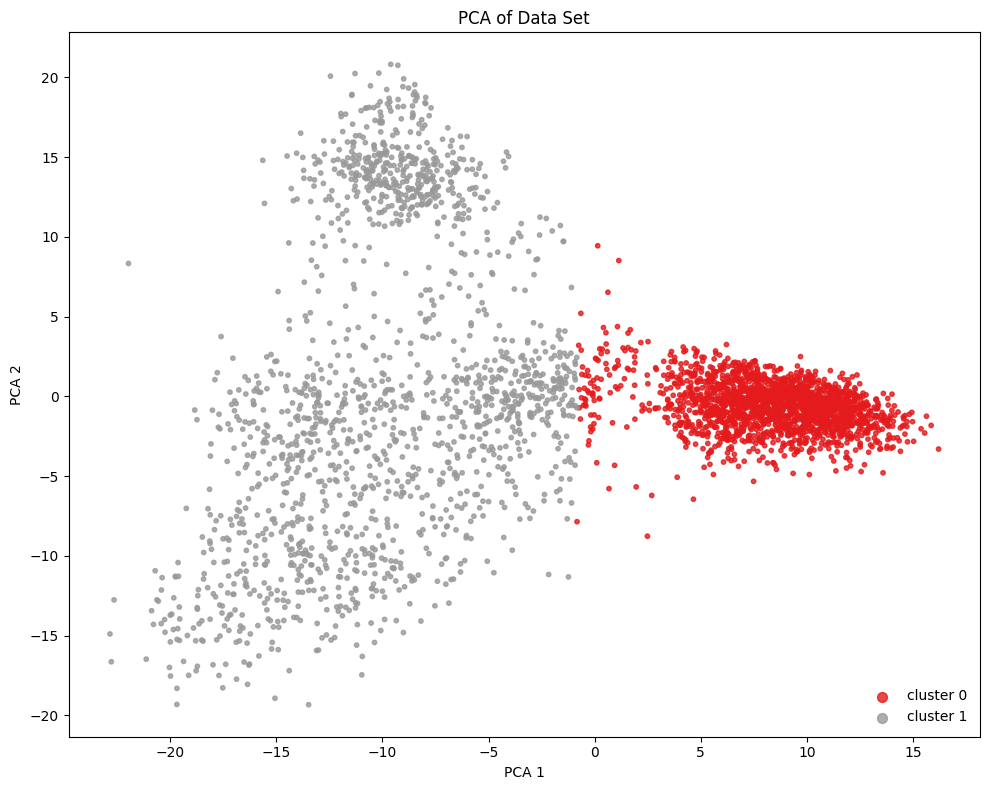

In [136]:
plot_dim_reduced_clustering(X, opt_labels, method='PCA')

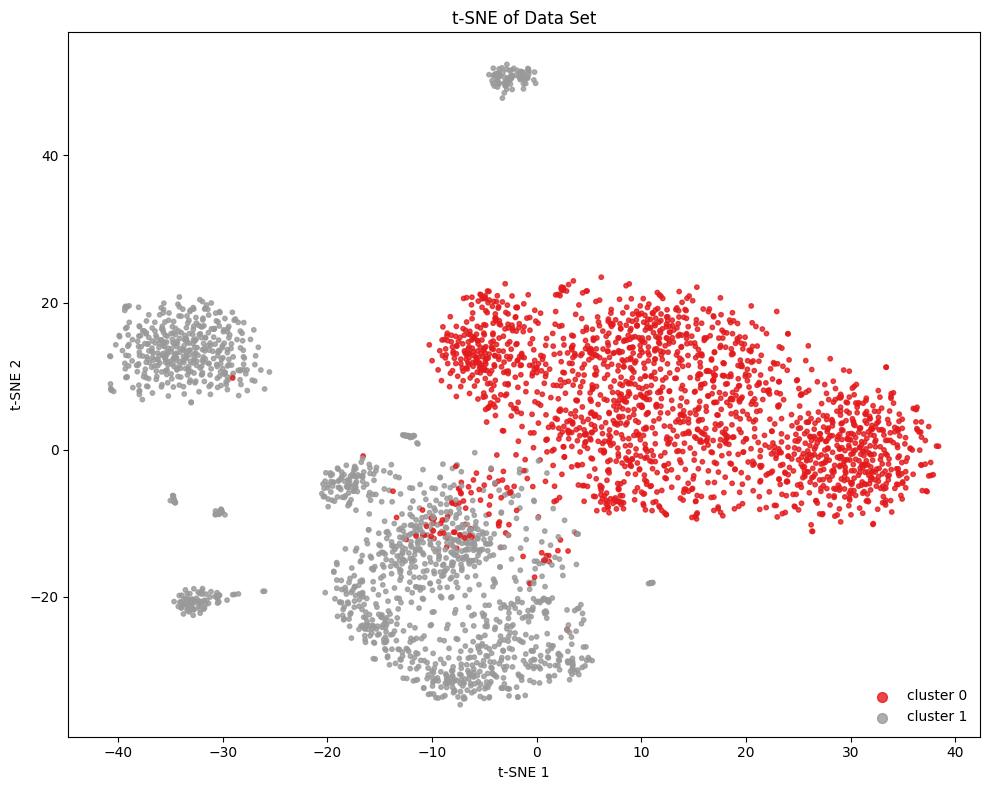

In [137]:
plot_dim_reduced_clustering(X, opt_labels, method='tSNE')

/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


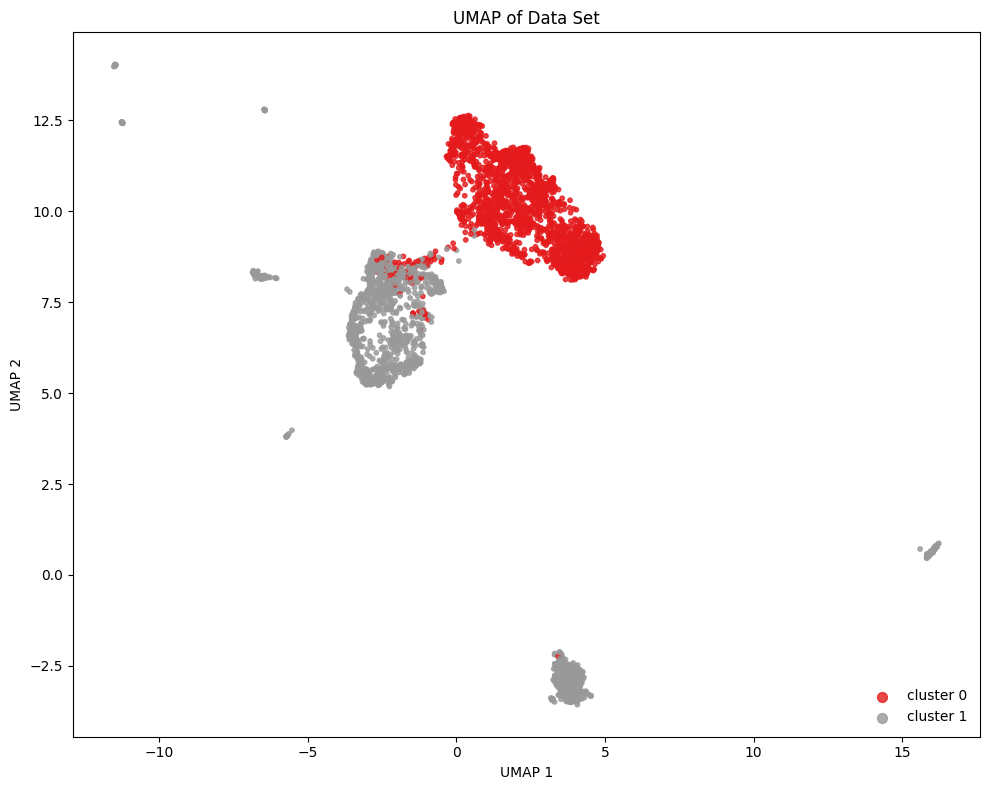

Exception ignored in: <function ResourceTracker.__del__ at 0x107a69620>
Traceback (most recent call last):
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106379620>
Traceback (most recent call last):
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
Chi

In [138]:
plot_dim_reduced_clustering(X, opt_labels, method='UMAP')

In [106]:
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.optimize import linear_sum_assignment

def map_clusterings(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    row_idx, col_idx = linear_sum_assignment(-cm)
    return dict(zip(col_idx, row_idx))

mapping = map_clusterings(y, opt_labels)

opt_labels_mapped = np.vectorize(mapping.get)(opt_labels)
print('accuracy:', accuracy_score(y, opt_labels_mapped))

ValueError: Mix of label input types (string and number)

Exception ignored in: <function ResourceTracker.__del__ at 0x102bcd620>
Traceback (most recent call last):
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10536d620>
Traceback (most recent call last):
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
Chi